In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt

color=['0.3', '0.5', '0.7', '0.9']
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

pd.set_option('display.max_rows', 6)
from IPython.display import HTML
import networkx as nx

In [2]:
# =============================================================================
#  APPLY THEME  --  Beamer "Madrid" look. Re-run any time to refresh styling.
# =============================================================================
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="03-Graphical-Models.ipynb",
)
import course_helpers as chh

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 23 cell(s):
 cell_index   slide_id                                  tags
          0            slide_hide_prompt, slide_remove_input
          1            slide_hide_prompt, slide_remove_input
          2            slide_hide_prompt, slide_remove_input
         10  slide-5-0 slide_hide_prompt, slide_remove_input
         13  slide-5-2 slide_hide_prompt, slide_remove_input
         15  slide-6-0 slide_hide_prompt, slide_remove_input
         17  slide-6-1 slide_hide_prompt, slide_remove_input
         19  slide-6-2 slide_hide_prompt, slide_remove_input
         21  slide-6-3 slide_hide_prompt, slide_remove_input
         23  slide-6-4 slide_hide_prompt, slide_remove_input
         25  slide-6-5 slide_hide_prompt, slide_remove_input
         28  slide-7-1 slide_hide_prompt, slide_remove_input
         31  slide-7-3 slide_hide_prompt, slide_remove_input
         33  slide-7-4                     slide_hide_prompt
         35  slide-7-5 slide_hide_prompt, sli

In [3]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

<div class="beamer-meta" data-author="Robert Pettis" data-date="Fall 2026"></div>

# Graphical Causal Models

### Causal Machine Learning

<br>

<b style="color:#73000A;">Robert Pettis</b>
Fall 2026

## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Lost?</span> <span style="color:#2a2a2a; font-size:1.06em;"><code>git status</code> is always safe and usually tells you what to do. The <b>Sync fork</b> button on GitHub does the pull for you.</span></div>

## Last Time

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Recap</span>

- Association $\neq$ causation, and the gap between them is <b style="color:#73000A;">bias</b>
- <b style="color:#73000A;">Potential outcomes:</b> $Y_1$ is what a unit's outcome would be if treated, $Y_0$ what the same unit's would be if not. Every unit has both, and we only ever see one
- The quantities we want:
  - <b style="color:#73000A;">ATE</b> $= E[Y_1 - Y_0]$, everyone
  - <b style="color:#73000A;">ATT</b> $= E[Y_1 - Y_0 \mid T{=}1]$, the treated
  - <b style="color:#73000A;">CATE</b> $= E[Y_1 - Y_0 \mid X{=}x]$, a group sharing $x$
- <b style="color:#73000A;">Randomization</b> removes the bias. Without it we have to argue the groups were comparable

Today: what bias looks like when nobody randomized.

## Where the Bias Term Comes From

$$E[Y \mid T{=}1] - E[Y \mid T{=}0] = \underbrace{E[Y_1 - Y_0 \mid T{=}1]}_{\text{effect (ATT)}} + (\underbrace{E[Y_0 \mid T{=}1] - E[Y_0 \mid T{=}0])}_{\text{BIAS}}$$

- The bias term is the gap between the two groups in what would have happened anyway
- It is zero when a coin flip decides who gets treated
- In almost all real data nobody flipped that coin, so the <b style="color:#73000A;">bias term is not zero</b>

## Big Questions

- What is the smallest set of variables we need to control for?
- Equally important, and usually forgotten: what should we <b style="color:#73000A;">not</b> control for?

### What Conditioning Actually Means

Blocking a path means comparing units that already match on $X$:

$$E[Y \mid D{=}1, X{=}x] - E[Y \mid D{=}0, X{=}x] \quad \text{at each value } x$$

- <b style="color:#73000A;">Put it in the regression.</b> Add $X$ as a control, read the coefficient on $D$
- <b style="color:#73000A;">Split the sample.</b> Estimate the effect inside each level of $X$, then average over the levels
- <b style="color:#73000A;">Match.</b> Pair each treated unit with an untreated unit holding the same $X$
- <b style="color:#73000A;">Weight.</b> Reweight the two groups until they carry the same distribution of $X$
- <b style="color:#73000A;">Select on it.</b> Keeping only some values of $X$ conditions on it too, meant or not

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:9px 15px; margin-top:12px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Vocabulary</span> <span style="color:#2a2a2a;">A.K.A. control for, adjust for, condition on, hold constant, partial out.</span></div>

## What a Causal Graph Is

A <b style="color:#73000A;">directed acyclic graph</b> is a set of nodes and arrows with no directed cycles.

- Nodes are variables
- Arrows are direct causal effects
- <b style="color:#73000A;">Direct</b> means the effect does not pass through another variable in the graph
- Dashed arrows come from causes we believe in but did not measure

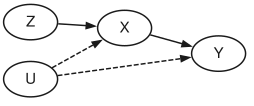

In [4]:
chh.draw_dag([("Z", "X"), ("X", "Y"),
              ("U", "X", "dashed"), ("U", "Y", "dashed")])

### About the graph
- Nothing left out, even when it cannot be measured
- The content comes from theory, prior studies, institutional knowledge, and judgment

### Reading a Graph

- $U$ is a <b style="color:#73000A;">parent</b> of $X$ and $Y$
- $X$ and $Y$ are <b style="color:#73000A;">descendants</b> of $Z$
- $Z \to X \to Y$ is a <b style="color:#73000A;">directed path</b>
- $Z \to X \leftarrow U$ is a <b style="color:#73000A;">path</b>, though not a directed one
- $X$ is a <b style="color:#73000A;">collider</b> on $Z \to X \leftarrow U$: two arrowheads meet there
- $X$ is a <b style="color:#73000A;">noncollider</b> on $Z \to X \to Y$
- Collider status belongs to the path, not to the node

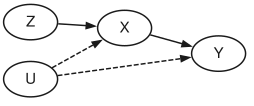

In [5]:
chh.draw_dag([("Z", "X"), ("X", "Y"),
              ("U", "X", "dashed"), ("U", "Y", "dashed")])

## Confounding

Confounding happens when treatment and outcome share a common cause.

- $X$ causes both $D$ and $Y$. That shape, $D \leftarrow X \to Y$, is a <b style="color:#73000A;">fork</b>
- The correlation holds two things at once: the causal effect, and the part $X$ creates
- Conditioning on $X$ separates them again: $D \perp Y \mid X$

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:9px 15px; margin-top:12px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Notation</span> <span style="color:#2a2a2a;">$D$ and $T$ both mean the treatment. Different books pick different letters, and both turn up in this course.</span></div>

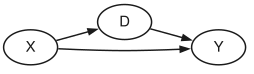

In [6]:
chh.draw_dag([("X", "D"), ("X", "Y"), ("D", "Y")])

### Selection Into Treatment: Who Takes the Supplement?

- Nobody assigns the supplement. People decide to take it
- The ones who do are the <b style="color:#73000A;">health conscious</b>: they exercise, they sleep, they see a doctor early
- Being health conscious eases joint pain on its own, supplement or no supplement
- So one cause sits above both, and that is a <b style="color:#73000A;">fork</b>
- Compare takers with non-takers and part of what you measure is the person, not the pill

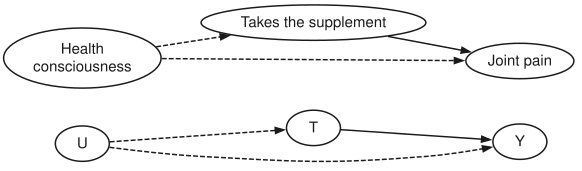

In [7]:
chh.draw_dag([("U", "T", "dashed"), ("U", "Y", "dashed"), ("T", "Y"),
              ("Health\nconsciousness", "Takes the supplement", "dashed"),
              ("Health\nconsciousness", "Joint pain", "dashed"),
              ("Takes the supplement", "Joint pain")])

### Backdoor Paths

- A <b style="color:#73000A;">backdoor path</b> runs from $D$ to $Y$ starting with an arrow into $D$: $D \leftarrow X \to Y$
- It carries correlation that is not causal
- Conditioning on $X$ blocks it, and what survives is the causal effect

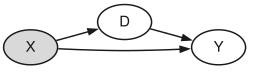

In [8]:
chh.draw_dag([("X", "D"), ("X", "Y"), ("D", "Y")], boxed={"X"})

### Watch It Happen: A Fork in Real Data

- Monthly US data, 1999 to 2020, $N = 264$
- Ice cream production and drowning deaths
- Correlation $= +0.50$. Nobody believes ice cream drowns people
- The fork: <b style="color:#73000A;">temperature</b> drives both

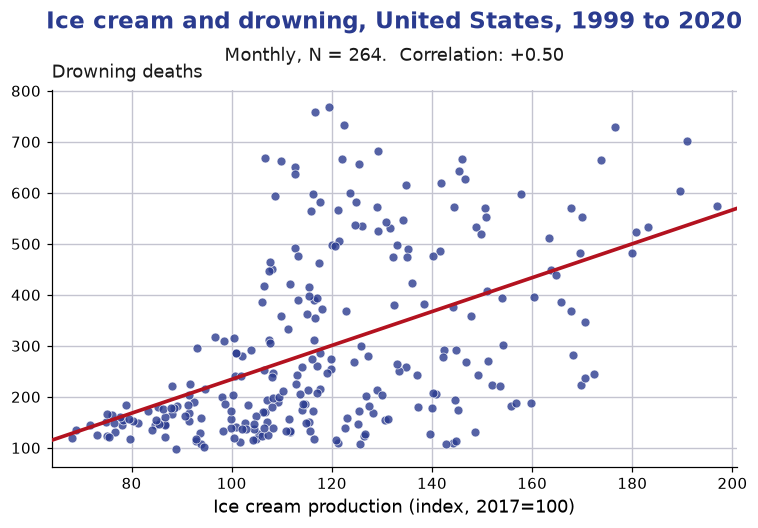

In [9]:
chh.fig_icecream_scatter()

### Closing the Backdoor Path

- Control for temperature
- Watch the colours scramble: temperature stops predicting position
- Association falls from $+0.50$ to $+0.15$, not to zero

In [10]:
HTML(chh.confounder_animation().to_html5_video())

### Selection on Unobservables Is a Fork

- Nobody assigns schooling. People choose how much of it to get
- Whatever drives that choice, call it $U$, tends to raise earnings on its own
- $U$ is unmeasured, so $\text{Schooling} \leftarrow U \to \text{Earnings}$ stays open
- The estimated return to schooling then carries whatever $U$ does with it
- Care with the regression cannot close a path through something never measured

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:9px 15px 7px 15px; margin-top:12px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Vocabulary</span><ul style="margin:7px 0 0 0; padding-left:22px; color:#2a2a2a;"><li style="margin:2px 0;">"Selection bias" in econometrics means this one: selection <b>into treatment</b></li><li style="margin:2px 0;">That is a fork, so it is confounding</li></ul></div>

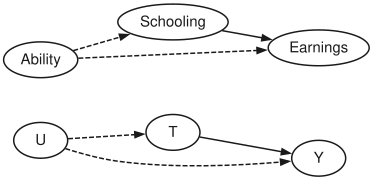

In [11]:
chh.draw_dag([("U", "T", "dashed"), ("U", "Y", "dashed"), ("T", "Y"),
              ("Ability", "Schooling", "dashed"),
              ("Ability", "Earnings", "dashed"),
              ("Schooling", "Earnings")])

## Collider Bias

- Also called <b style="color:#73000A;">endogenous selection bias</b>
- It starts from a common <b style="color:#73000A;">outcome</b>, not a common cause
- $T \to X \leftarrow Y$ is a <b style="color:#73000A;">collider</b> at $X$: two arrowheads meet there
- $T$ and $Y$ start out independent, and conditioning on $X$ makes them dependent
- Conditioning on a descendant of $X$ does the same thing, more weakly

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:9px 15px 7px 15px; margin-top:12px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Careful</span><ul style="margin:7px 0 0 0; padding-left:22px; color:#2a2a2a;"><li style="margin:2px 0;">Selection <b>into treatment</b> is a fork, and conditioning <b>fixes</b> it</li><li style="margin:2px 0;">Selection <b>into the sample</b> is a collider, and conditioning <b>caused</b> it</li></ul></div>

### Are Beauty and Talent Related?

- A 2009 CNN article reported that Megan Fox was voted both the worst and the most attractive actress of the year
- So are beauty and talent negatively related?
- Or are we looking only at the people famous enough to be on the ballot?
- <b style="color:#73000A;">No arrow between beauty and talent.</b> That absence is the claim, and the simulation enforces it

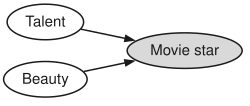

In [12]:
chh.draw_dag([("Talent", "Movie star"), ("Beauty", "Movie star")],
             boxed={"Movie star"})

### Watch It Happen: Conditioning on a Collider

- Beauty and talent, drawn <b style="color:#73000A;">independently</b>
- "Movie star" $=$ top 15% on beauty $+$ talent: a collider
- Look inside the groups, not just at the pooled cloud
- <b style="color:#73000A;">This is selection into the sample:</b> the sample IS the conditioning

### Watch It Happen: Conditioning on a Collider

In [14]:
HTML(chh.collider_animation().to_html5_video())

### Let's show the simulation

- Draw beauty and talent independently for 2500 people
- Call the top 15 percent on beauty plus talent a movie star
- Nothing in the code links beauty to talent

In [15]:
rng = np.random.default_rng(3444)
n = 2500
beauty = rng.normal(0, 1, n)
talent = rng.normal(0, 1, n)                # independent by construction
score = beauty + talent
star = score >= np.quantile(score, 0.85)    # the collider: a common outcome

print(f"correlation, everyone     {np.corrcoef(beauty, talent)[0, 1]:+.2f}")
print(f"correlation, stars only   {np.corrcoef(beauty[star], talent[star])[0, 1]:+.2f}")
print(f"correlation, not stars    {np.corrcoef(beauty[~star], talent[~star])[0, 1]:+.2f}")

correlation, everyone     -0.01
correlation, stars only   -0.64
correlation, not stars    -0.25


### Conditioning on the Top 15 Percent

- Split the sample on stardom and the slope turns negative inside <b style="color:#73000A;">both</b> groups
- Pool them back together and it is flat again
- The negative relationship is manufactured by the split

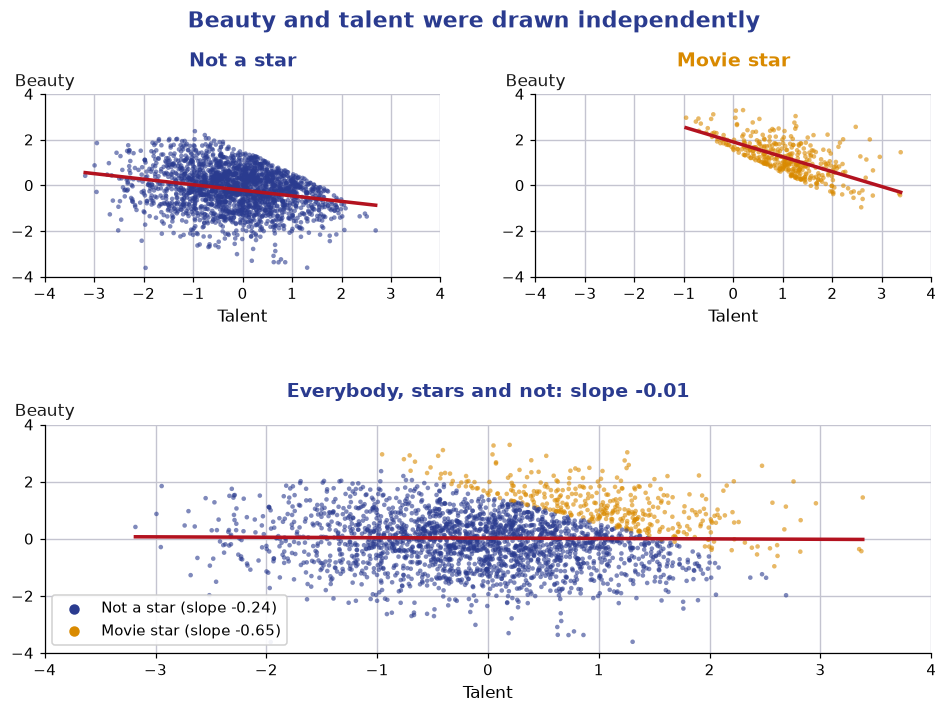

In [16]:
chh.fig_collider_panels()

### Selection Into the Sample: Recruiting at a Clinic

- <b style="color:#73000A;">The same study:</b> does a supplement relieve joint pain?
- Earlier the danger was who chooses the pill. Now it is who ends up in the data
- We recruit subjects in the waiting room of an orthopaedic practice
- Two things put a person in that room: <b style="color:#73000A;">joint pain</b>, and being the sort who <b style="color:#73000A;">takes supplements</b> and comes in for checkups
- Sitting in the room is caused by both, so it is a <b style="color:#73000A;">collider</b>
- Recruiting there conditions on it, before we measure anything
- The arrow we want is <b style="color:#73000A;">supplement to joint pain</b>. Recruiting adds a second, non-causal route
- Among our subjects, someone with no joint pain is probably there for the other reason, so the supplement looks <b style="color:#73000A;">more protective than it is</b>

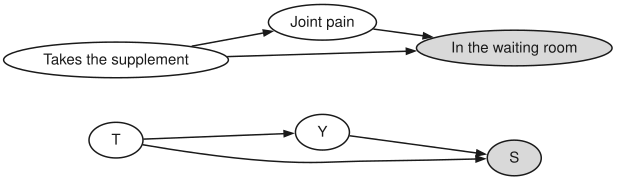

In [17]:
chh.draw_dag([("T", "Y"), ("T", "S"), ("Y", "S"),
              ("Takes the supplement", "Joint pain"),
              ("Takes the supplement", "In the waiting room"),
              ("Joint pain", "In the waiting room")],
             boxed={"S", "In the waiting room"})

## Mediator (Overcontrol) Bias

- The third failure mode: closing a path we needed open
- $A \to C \to B$ is a <b style="color:#73000A;">chain</b>, and $C$ is a <b style="color:#73000A;">mediator</b>
- $A$ and $B$ are dependent, and conditioning on $C$ separates them
- Here that is the wrong move: the effect of $A$ on $B$ is real, and it runs <b style="color:#73000A;">through</b> $C$

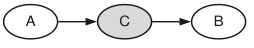

In [18]:
chh.draw_dag([("A", "C"), ("C", "B")], boxed={"C"})

### In Other Words

- $C$ does not close a backdoor, because there is no backdoor here
- $C$ sits on the path we wanted to measure
- The effect of $A$ on $B$ then looks small or absent, however large it really is
- Anything measured after treatment deserves this suspicion

### Example: Cigars and Health

- Price of cigars, number of cigars smoked, health
- Price reaches health only by changing how much people smoke
- Control for how much people smoke and price looks irrelevant to health

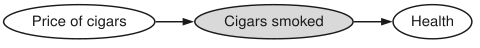

In [19]:
chh.draw_dag([("Price of cigars", "Cigars smoked"),
              ("Cigars smoked", "Health")],
             boxed={"Cigars smoked"})

### Watch It Happen: Overcontrol

- A made up cigar market: 600 towns, prices differ, people respond
- Price moves smoking, smoking moves health, and price touches health no other way
- Residualize price <b style="color:#73000A;">and</b> health on cigars smoked
- The line goes flat: <b style="color:#73000A;">+1.48</b> a dollar becomes <b style="color:#73000A;">-0.03</b>
- Nothing spurious was removed. The whole effect ran through the mediator

In [21]:
HTML(chh.mediator_animation().to_html5_video())

### Mediation Analysis

But what if the mediators are the interesting part? Try mediation analysis.

In [22]:
chh.mediation_puzzle()

### How to Fix and Still Get the Whole Picture

In [23]:
chh.mediation_solution()

## When Conditioning Is Not Enough

- Some backdoor paths run through variables nobody measured
- The answer is then a research design, not a longer list of controls
- <b style="color:#73000A;">Regression discontinuity:</b> a sharp cutoff decides who is treated
- <b style="color:#73000A;">Difference in differences:</b> two groups on parallel paths, one of them treated
- <b style="color:#73000A;">Instrumental variables:</b> something moves treatment and reaches the outcome no other way
- <b style="color:#73000A;">Matching and propensity scores:</b> compare like with like on what was measured

## Quiz: There Is More Than One Way

Which of these would <b style="color:#73000A;">not</b> identify the causal effect of $D$ on $Y$? Choose all that apply.

1. Condition on $F$
2. Condition on $A$
3. Condition on $B$
4. Condition on $A$ and $B$ together
5. Use $C$ as an instrument

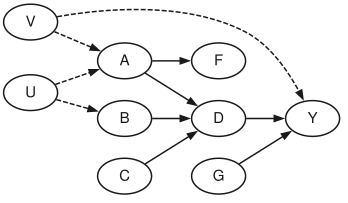

In [24]:
chh.draw_dag([("V", "A", "dashed"), ("V", "Y", "dashed"),
              ("U", "A", "dashed"), ("U", "B", "dashed"),
              ("A", "F"), ("A", "D"), ("B", "D"), ("C", "D"),
              ("D", "Y"), ("G", "Y")])

## Key Ideas

- A DAG turns an argument about causation into something other people can check
- Conditioning on a <b style="color:#73000A;">confounder</b> blocks a path, and that is the fix for confounding
- Conditioning on a <b style="color:#73000A;">collider</b>, or on anything it caused, opens a path that was closed
- Conditioning on anything <b style="color:#73000A;">downstream of treatment</b> dilutes real effect
- Conditioning is neither good nor bad on its own. The situation decides

### The Flow of Association Cheat Sheet

- <b style="color:#73000A;">Chain:</b> blocks when conditioned on the middle node
- <b style="color:#73000A;">Fork:</b> blocks when conditioned on the parent
- <b style="color:#73000A;">Collider:</b> blocks when NOT conditioned; opens when conditioned on the collider or its descendants

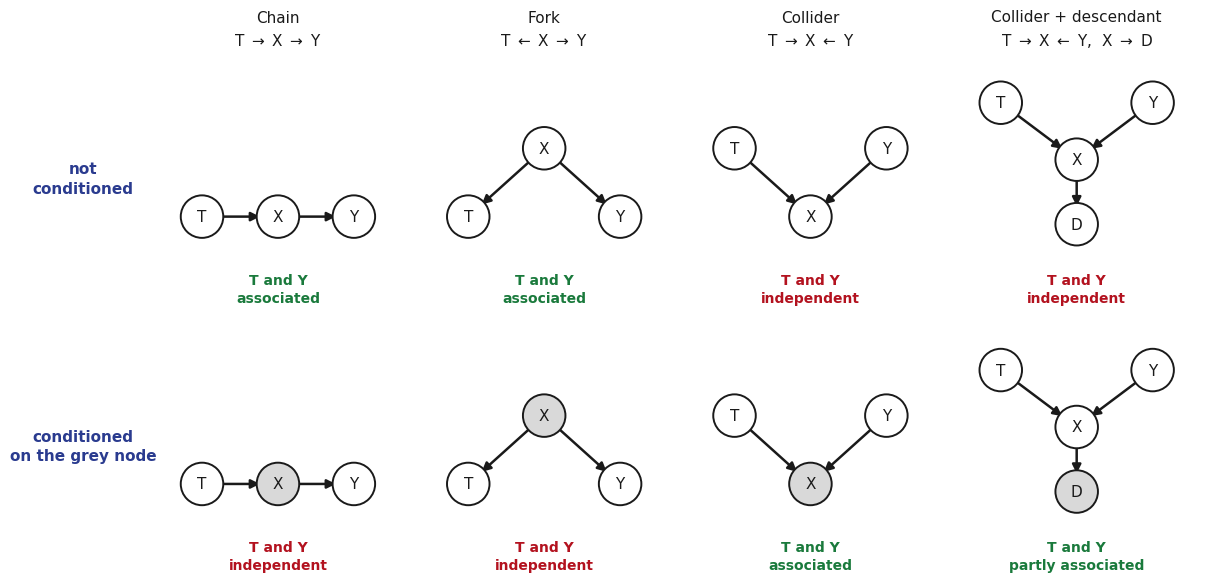

In [23]:
chh.fig_association_cheatsheet()